# Assignment 1: Do-It-Yourself Deep Learning


This assignment guides you through implementing fundamental building blocks of deep networks from scratch using NumPy, and then transitioning to PyTorch for a comparison. You will derive and implement forward output computation, backward gradient computation, and optimization updates. You will then explore different nonlinearities and initialization schemes, analyze the impact of network depth, and experiment with how accurate you can make your first deep learning system.


---


## Problem 1: Linear and  Nonlinear Model


In this problem, you will implement a basic deep network with a single linear layer, introduce various nonlinearities, and then build a more complex model incorporating a novel nonlinearity. You will implement the forward pass, backward pass, and stochastic gradient descent (SGD) updates from scratch.


### Setup and Imports


In [68]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

# For TensorBoard visualization
%load_ext tensorboard
import tensorflow as tf
import datetime

print("Libraries loaded successfully.")

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard
Libraries loaded successfully.


### Data Preparation

We will use a subset of **CIFAR-10** for a multi-class classification task. The images are flattened into feature vectors so that we can focus on implementing fully connected deep-network components from scratch.


In [69]:
# Download the preprocessed CIFAR-10 dataset
!gdown "https://drive.google.com/file/d/1ib-QphcaBHswISn160dYMtDHmy_Py4jL/view?usp=sharing" -O cifar10.npz 

Using cookies from /Users/jaden/.cache/gdown/cookies.txt
Downloading...
From (original): https://drive.google.com/uc?id=1ib-QphcaBHswISn160dYMtDHmy_Py4jL
From (redirected): https://drive.google.com/uc?id=1ib-QphcaBHswISn160dYMtDHmy_Py4jL&confirm=t&uuid=a7d20fa4-a63b-4f16-88b8-381b675292d7
To: /Users/jaden/Documents/University Notes/2026W/AI 360/Assignment1/cifar10.npz
100%|███████████████████████████████████████| 170M/170M [00:07<00:00, 23.1MB/s]


CIFAR-10 X_train shape: (25000, 3072), y_train shape: (25000, 1)
CIFAR-10 X_test shape: (5000, 3072), y_test shape: (5000, 1)
Number of classes: 5
y_train_one_hot shape: (25000, 5)
y_test_one_hot shape: (5000, 5)


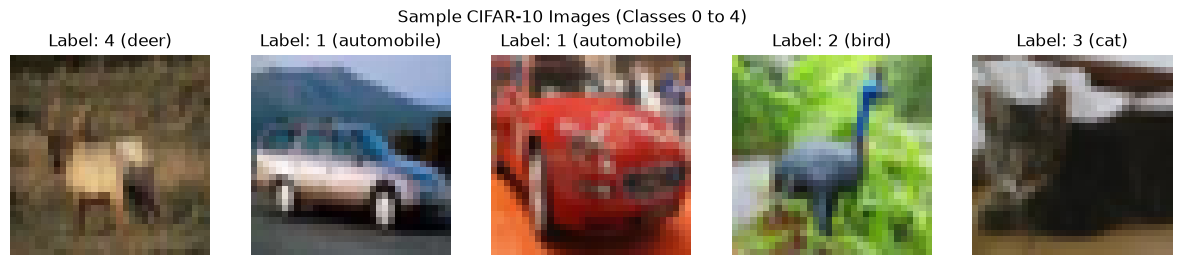

In [70]:
import numpy as np # Import numpy

# Load CIFAR-10 dataset
data = np.load("cifar10.npz")

X_train_raw = data["X_train"]
y_train_raw = data["y_train"]
X_test_raw = data["X_test"]
y_test_raw = data["y_test"]

# Define the number of classes for multi-class classification (e.g., first 5 classes)
num_classes_to_use = 5 # airplane, automobile, bird, cat, deer

# Filter for selected classes in training data
mask_train = (y_train_raw < num_classes_to_use).flatten()
X_train = X_train_raw[mask_train]
y_train = y_train_raw[mask_train]

# Filter for selected classes in testing data
mask_test = (y_test_raw < num_classes_to_use).flatten()
X_test = X_test_raw[mask_test]
y_test = y_test_raw[mask_test]

# Flatten images: (num_samples, 32, 32, 3) -> (num_samples, 3072)
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

# Normalize pixel values to [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Ensure y is a column vector
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

# One-hot encode labels for multi-class classification
y_train_one_hot = np.eye(num_classes_to_use)[y_train.flatten()]
y_test_one_hot = np.eye(num_classes_to_use)[y_test.flatten()]

print(f"CIFAR-10 X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"CIFAR-10 X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")
print(f"Number of classes: {num_classes_to_use}")
print(f"y_train_one_hot shape: {y_train_one_hot.shape}")
print(f"y_test_one_hot shape: {y_test_one_hot.shape}")

# --- Visualize a few samples ---
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
fig.suptitle(f"Sample CIFAR-10 Images (Classes 0 to {num_classes_to_use-1})")

# CIFAR-10 class names for better visualization
cifar10_class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

for i, ax in enumerate(axes):
    # Reshape flattened image back to 32x32x3 for display
    img = X_train[i].reshape(32, 32, 3)
    ax.imshow(img)
    label_idx = y_train[i, 0]
    ax.set_title(f"Label: {label_idx} ({cifar10_class_names[label_idx]})")
    ax.axis('off')
plt.show()

### Part 1.1: Forward Propagation with a Linear Layer

We first implement the forward operation of a linear layer,

$$Z = XW + b.$$

We begin with the forward computation before assembling the full training procedure. The same `Linear` class will be reused throughout the assignment.

For now, focus on completing `forward()`. In Part 1.3, you will return to this same class and complete `backward()`.

**Do not create another `Linear` class later.**

In [96]:
def random_normal_init(input_dim, output_dim):
    W = np.random.randn(input_dim, output_dim) / np.sqrt(input_dim)
    b = np.zeros((1, output_dim))
    return W, b


class Linear:
    def __init__(self, input_dim, output_dim,
                 initialization_fn=random_normal_init):
        self.input_dim = input_dim
        self.output_dim = output_dim

        self.W, self.b = initialization_fn(input_dim, output_dim)

        self.X = None
        self.dW = None
        self.db = None


    def forward(self, X):
        # TODO: Implement Z = XW + b.
        # Store X because it will be needed in backward().
        self.X = X
        Z = X @ self.W + self.b
        return Z

    def backward(self, dZ):
        # TODO (Part 1.3): Reuse this SAME class and implement backward propagation.
        # Compute self.dW, self.db, and dX.
        # print(f'shapes:')
        # print(f'dZ{dZ.shape}:\n{dZ}')
        # print(f'W{self.W.shape}:\n{self.W}')
        # print(f'b{self.b.shape}:\n{self.b}')
        # print(f'X{self.X.shape}:\n{self.X}')

        self.dW = self.X.T @ dZ
        # print(f'dW{self.dW.shape}:\n{self.dW}')
        self.db = np.array([np.sum(dZ, axis = 0)])

        # print(f'db{self.db.shape}:\n{self.db}')
        dX = dZ @ self.W.T
        # print(f'dX{dX.shape}:\n{dX}')
        return dX

    def get_params(self):
        return self.W, self.b

    def set_params(self, W, b):
        self.W = W
        self.b = b

    def get_grads(self):
        return self.dW, self.db


Let's verify that the forward operation produces an output with the expected shape. You dont need to change the code below.

In [97]:
# Validation for Part 1.1: check the forward computation numerically. You dont need to change the code here.

linear_check = Linear(3, 2)
linear_check.W = np.array([
    [1.0, 2.0],
    [3.0, 4.0],
    [5.0, 6.0],
])
linear_check.b = np.array([[0.5, -0.5]])

X_check = np.array([
    [1.0, 0.0, 1.0],
    [0.0, 1.0, 1.0],
])

expected = np.array([
    [6.5, 7.5],
    [8.5, 9.5],
])

actual = linear_check.forward(X_check)
assert np.allclose(actual, expected)
print("Part 1.1 numerical forward check passed!")


Part 1.1 numerical forward check passed!


### Part 1.2: Loss Function

After computing the model outputs, we need to compare them with the correct class labels. For this multi-class classification task, we use **Softmax + Categorical Cross-Entropy (CCE)**.

For logits $z$, Softmax produces

$$\hat{y}_j = \frac{e^{z_j}}{\sum_k e^{z_k}},$$

and the categorical cross-entropy loss is

$$L = -\frac{1}{B}\sum_{i=1}^{B}\sum_j y_{ij}\log \hat{y}_{ij}.$$

Implement both the **forward** and **backward** operations. When Softmax and CCE are combined, the gradient with respect to the logits simplifies to

$$\frac{\partial L}{\partial z}
=
\frac{\hat{y}-y}{B}.$$

Therefore, you do not need a separate `Softmax.backward()` class.

In [73]:
class CategoricalCrossEntropyLoss:
    def __init__(self):
        self.y_true = None
        self.y_pred_softmax = None

    def forward(self, y_true, y_pred_logits):
        # y_true: one-hot labels with shape (batch_size, num_classes)
        # y_pred_logits: logits with shape (batch_size, num_classes)

        # print(f'y_true:\n{y_true}')
        # print(f'y_pred_logits:\n{y_pred_logits}')

        # TODO:
        # 1. Compute a numerically stable Softmax.
        # 2. Store y_true and the Softmax probabilities.
        # 3. Clip probabilities before log() if needed.
        # 4. Compute and return the mean categorical cross-entropy loss.
        self.y_true = y_true
        y_pred_squashed = np.subtract(y_pred_logits.T, np.max(y_pred_logits, axis = 1)).T
        # print(f'y_pred_squashed:\n{y_pred_squashed}')

        exp_logits = np.exp(y_pred_squashed)
        # print(f'exp_logits:\n{exp_logits}')
        self.y_pred_softmax = (exp_logits.T / np.sum(exp_logits, axis=1)).T
        # print(f'y_pred_softmax:\n{self.y_pred_softmax}')
        batch_size = len(y_true)
        loss = -1 / batch_size * np.sum(np.sum(self.y_true*np.log(self.y_pred_softmax)))
        # print(loss)
        return loss

    def backward(self):
        # TODO:
        # Return dL/dlogits for the combined Softmax + CCE operation.
        # Remember to account for the batch size.
        batch_size = len(self.y_true)
        grad_logits = np.subtract(self.y_pred_softmax, self.y_true) / batch_size
        return grad_logits


Let's test the loss on a small batch. You dont need to change the code below.

In [74]:
# Validation for Part 1.2: Softmax/CCE

# A small normal example
example_logits = np.array([
    [1.0, 2.0, 3.0],
    [2.0, 1.0, 0.0],
])

example_labels = np.array([
    [0.0, 0.0, 1.0],
    [1.0, 0.0, 0.0],
])

loss_fn_example = CategoricalCrossEntropyLoss()

loss_example = loss_fn_example.forward(
    example_labels,
    example_logits
)

grad_logits_example = loss_fn_example.backward()
probs_example = loss_fn_example.y_pred_softmax

# Check output shapes
assert np.isscalar(loss_example)
assert grad_logits_example.shape == example_logits.shape

# Softmax probabilities should sum to 1
assert np.allclose(
    np.sum(probs_example, axis=1),
    np.ones(probs_example.shape[0])
)

assert np.all(probs_example >= 0)
assert np.all(probs_example <= 1)

# Loss and gradients should be finite
assert np.isfinite(loss_example)
assert np.all(np.isfinite(grad_logits_example))

# Since we've constructed the example logits and labels to be correct (argmax of logits is the right label),
# We expect the loss to be lower than an incorrect prediction
# Here example_labels[::-1] switch the labels for the two samples, so predictions are no longer correct.
assert loss_fn_example.forward(example_labels, example_logits) < loss_fn_example.forward(example_labels[::-1], example_logits)

# we do a step of gradient descent on the logits, to verify that loss is indeed lower.
updated_logits=example_logits-grad_logits_example
assert loss_fn_example.forward(example_labels,updated_logits)<loss_example


# --------------------------------------------------
# Check numerical stability using very large logits
# --------------------------------------------------

extreme_logits = np.array([
    [1000.0, 999.0, 998.0],
    [-1000.0, -999.0, -998.0],
])

extreme_labels = np.array([
    [1.0, 0.0, 0.0],
    [0.0, 0.0, 1.0],
])

extreme_loss_fn = CategoricalCrossEntropyLoss()

extreme_loss = extreme_loss_fn.forward(
    extreme_labels,
    extreme_logits
)

extreme_grad = extreme_loss_fn.backward()

assert np.isfinite(extreme_loss)
assert np.all(np.isfinite(extreme_grad))
# print(extreme_loss_fn.y_pred_softmax)
assert np.allclose(
    np.sum(extreme_loss_fn.y_pred_softmax, axis=1),
    np.ones(extreme_logits.shape[0])
)

print("Part 1.2 Softmax/CCE validation passed!")

Part 1.2 Softmax/CCE validation passed!


### Part 1.3: Backward Propagation

Backpropagation applies the chain rule through the sequence of operations in the model.

For our current model,

$$X \rightarrow \text{Linear} \rightarrow \text{Softmax + CCE}.$$

The backward computation therefore proceeds in the reverse order:

$$\text{Loss.backward()}
\rightarrow
\text{Linear.backward()}.$$

**Task:** Return to the `Linear` class from Part 1.1 and complete its `backward()` method. Do **not** define a new `Linear` class.

Your implementation should compute:

- the gradient with respect to the weights, $dW$, **store** in `self.dW`
- the gradient with respect to the bias, $db$, **store** in `self.db`
- and the gradient with respect to the input, $dX$, **return** it

Then use the code below to test one complete forward/backward pass.

In [75]:
# Validation for Part 1.3: check Linear.backward() numerically.

rng = np.random.default_rng(0)
X_check = rng.normal(size=(3, 4))
dZ_check = rng.normal(size=(3, 2))

linear_check = Linear(4, 2)

# Use deterministic parameters for the check.
linear_check.W = rng.normal(size=(4, 2))
linear_check.b = rng.normal(size=(1, 2))

# Analytical gradients.
Z_check = linear_check.forward(X_check)
dX_check = linear_check.backward(dZ_check)

assert linear_check.dW.shape == linear_check.W.shape
assert linear_check.db.shape == linear_check.b.shape
assert dX_check.shape == X_check.shape

# Numerical gradient for W using the scalar function sum(Z * dZ).
epsilon = 1e-5
numerical_dW = np.zeros_like(linear_check.W)

for i in range(linear_check.W.shape[0]):
    for j in range(linear_check.W.shape[1]):
        original = linear_check.W[i, j]

        linear_check.W[i, j] = original + epsilon
        plus = np.sum(linear_check.forward(X_check) * dZ_check)

        linear_check.W[i, j] = original - epsilon
        minus = np.sum(linear_check.forward(X_check) * dZ_check)

        numerical_dW[i, j] = (plus - minus) / (2 * epsilon)
        linear_check.W[i, j] = original

assert np.allclose(
    linear_check.dW, numerical_dW, rtol=1e-5, atol=1e-7
)

print("Part 1.3 backward/gradient check passed!")


Part 1.3 backward/gradient check passed!


### Part 1.4: Stochastic Gradient Descent for a Single-Layer Linear Model

We now train the single-layer linear classifier.

In each mini-batch:

1. run the linear-layer forward pass,
2. compute the loss,
3. run the loss backward pass,
4. run the linear-layer backward pass,
5. update the linear-layer parameters with SGD.

**Task 1:**
Shuffle and batch your training set.

`batch_size` denotes the number of training samples in each mini-batch


In [76]:
def iterate_batches(X, y, batch_size):
    permutation = np.random.permutation(X.shape[0])
    X_shuffled = X[permutation]
    y_shuffled = y[permutation]
    for i in range(0, len(X), batch_size):
        X_batch = X_shuffled[i: i+batch_size]
        y_batch = y_shuffled[i: i+batch_size]
        yield X_batch, y_batch



**Task 2:**
implement the One Linear Layer GD update

$$W \leftarrow W - \lambda \frac{\partial L}{\partial W},
\qquad
b \leftarrow b - \lambda \frac{\partial L}{\partial b}.$$


In [77]:
class OneLayerGD:
    def __init__(self, layer, lr):
        self.layer = layer
        self.lr = lr
    def step(self):
        for p, g in zip(self.layer.get_params(), self.layer.get_grads()):
            p -= self.lr * g


**Task 3:**
implement the training loop


In [ ]:
def train_batch(model, loss_fn, opt, xbatch, ybatch):
    # HINTS:
    # 1. compute logits
    # 2. compute loss
    logits = model.forward(xbatch)
    loss = loss_fn.forward(ybatch, logits)

    # TODO:
    # 3. compute gradients
    model.backward(loss_fn.backward())

    # 4. update paraemters by one step of optimization
    opt.step()

    n_correct = np.sum(np.argmax(logits, axis=1) == np.argmax(ybatch, axis=1))
    return loss * len(xbatch), n_correct

def eval_step(model, loss_fn, X, y):
    logits = model.forward(X)
    loss = loss_fn.forward(y, logits)
    n_correct = n_correct = np.sum(np.argmax(logits, axis=1) == np.argmax(y, axis=1))
    return loss * len(X), n_correct


def train(model, loss_fn, opt, X_train, y_train, X_test, y_test,
          epochs, batch_size, log_every=1):
    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
    n_train, n_test = len(X_train), len(X_test)

    # Step 0: performance of the untrained model
    tr_loss, tr_correct = eval_step(model, loss_fn, X_train, y_train) # TODO
    te_loss, te_correct = eval_step(model, loss_fn, X_test, y_test) # TODO
    print(f"Untrained   | "
          f"Train loss: {tr_loss / n_train:.4f}, accuracy: {tr_correct / n_train:.2%} | "
          f"Test loss: {te_loss / n_test:.4f}, accuracy: {te_correct / n_test:.2%}")

    for epoch in range(epochs):
        loss_sum, correct = 0.0, 0
        for xb, yb in iterate_batches(X_train, y_train, batch_size): # TODO
            l, c = train_batch(model, loss_fn, opt, xb, yb) # TODO
            loss_sum.append(l
            correct.append(c

        te_loss, te_correct = eval_step(model, loss_fn, X_test, y_test)

        for k, v in zip(history, (loss_sum / n_train, correct / n_train,
                                  te_loss / n_test, te_correct / n_test)):
            history[k].append(v)

        if (epoch + 1) % log_every == 0:
            print(f"Epoch {epoch + 1:02d}/{epochs} | "
                  f"Train loss: {history['train_loss'][-1]:.4f}, accuracy: {history['train_acc'][-1]:.2%} | "
                  f"Test loss: {history['test_loss'][-1]:.4f}, accuracy: {history['test_acc'][-1]:.2%}")
    return history

With these functions you just implemented, we can now train a one-layer linear model using gradient descent.

In [79]:

# Single-layer linear model, trained with the shared train() loop.

learning_rate = 0.001
epochs = 20
batch_size = 32

np.random.seed(0)
model_linear = Linear(X_train.shape[1], num_classes_to_use)
loss_fn = CategoricalCrossEntropyLoss()
opt = OneLayerGD(model_linear, lr=learning_rate)


history_linear = train(model_linear, loss_fn, opt,
                       X_train, y_train_one_hot, X_test, y_test_one_hot,
                       epochs=epochs, batch_size=batch_size, log_every=5)


Untrained   | Train loss: 1.6847, accuracy: 18.13% | Test loss: 1.6853, accuracy: 18.10%
Epoch 05/20 | Train loss: 1.2589, accuracy: 50.93% | Test loss: 1.2529, accuracy: 50.72%
Epoch 10/20 | Train loss: 1.2227, accuracy: 52.80% | Test loss: 1.2344, accuracy: 50.76%
Epoch 15/20 | Train loss: 1.2046, accuracy: 53.66% | Test loss: 1.2143, accuracy: 52.26%
Epoch 20/20 | Train loss: 1.1930, accuracy: 54.39% | Test loss: 1.1992, accuracy: 53.70%


**Now, what exactly did we just train?**

One cool thing about linear models is that they can be more interpretable.
For example, let's try to visualize this model we just trained.

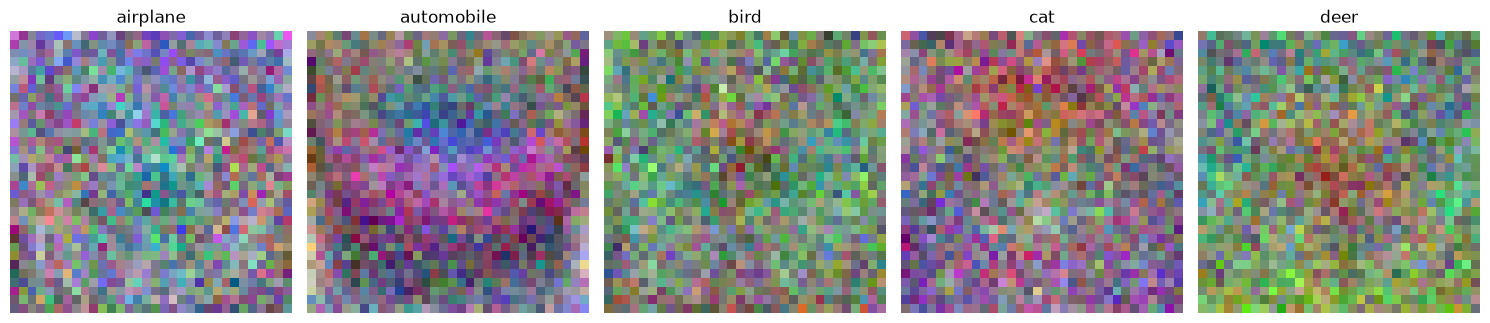

In [80]:
W, b = model_linear.get_params()

fig, axes = plt.subplots(1, num_classes_to_use, figsize=(15, 3.5))
for k, ax in enumerate(axes):
    w = W[:, k].reshape(32, 32, 3)
    w = (w - w.min()) / (w.max() - w.min())
    ax.imshow(w)
    ax.set_title(cifar10_class_names[k])
    ax.axis("off")
plt.tight_layout()
plt.show()

What can you observe from the visualized weights? Why do they look like this?

**TODO**: YOUR ANSWER HERE

The visualized weights look like very noisy representations of their training data to me, The bird appears to be a small brown ish blob in a green background while the deer is a larger brownish blob. The automobile appears to be a red subject with a noisy background, while the airplane is a bright centered subject with a darker background.

### Part 1.5: Nonlinear Activation Functions and Their Gradients

A stack of linear layers without a nonlinear activation is still equivalent to a single linear transformation. We therefore introduce nonlinear activation functions.

Before implementing the activations, define the following base `Layer` class:

In [81]:
class Layer:
    def get_params(self):
        return ()

    def get_grads(self):
        return ()

All activation functions implemented in this section should inherit from `Layer`. Since activation functions do not have trainable parameters, they can directly use the default `get_params()` and `get_grads()` implementations.

**We will consider three activation functions:**

1. Sigmoid
2. ReLU
3. PN-ReLU

Implement both the **forward** and **backward** operations of each activation. These activation classes will be reused in later sections.


#### Sigmoid

$$\sigma(x)=\frac{1}{1+e^{-x}}.$$

**Task:** Derive $$\frac{\partial \sigma(x)}{\partial x}$$ and implement the forward and backward operations.

In [82]:
class Sigmoid(Layer):
    def __init__(self):
        self.output = None

    def forward(self, x):
        # Note: We clip large values to avoid numerical instability in exp().
        x = np.clip(x, -500, 500)

        # TODO: Implement Sigmoid and store its output.
        self.output = 1 / (1+np.exp(-1 * x))
        return self.output

    def backward(self, d_output):
        # TODO: Backpropagate d_output through Sigmoid.
        d_input = d_output * (self.output * np.subtract(1, self.output))
        return d_input


#### ReLU

$$\mathrm{ReLU}(x)=\max(0,x).$$

**Task:** Derive its gradient and implement the forward and backward operations.

In [83]:
class ReLU(Layer):
    def __init__(self):
        self.input = None

    def forward(self, x):
        # TODO: Implement ReLU and store the input.
        self.input = x
        return np.maximum(x, 0)

    def backward(self, d_output):
        # TODO: Backpropagate d_output through ReLU.
        d_input = d_output * (self.input > 0)
        return d_input


#### PN-ReLU (Positive-Negative ReLU)

We also consider the following custom activation:

$$\mathrm{PNReLU}(x)
=
\mathrm{concat}\left(\max(0,x),\min(0,x)\right).$$

The output feature dimension is twice the input feature dimension.

**Task:** Derive the gradient for both output components and implement the forward and backward operations.

In [84]:
class PNReLU(Layer):
    def __init__(self):
        self.input = None

    def forward(self, x):
        # TODO: Concatenate the positive and negative parts.
        self.input = x
        output = np.concat([np.maximum(x, 0), np.minimum(x, 0)], axis=1)
        return output

    def backward(self, d_output):
        # TODO:
        # 1. Split d_output into gradients for the two halves.
        # 2. Backpropagate each half through its corresponding branch.
        # 3. Add the two contributions to obtain d_input.
        d_positive, d_negative = np.split(d_output, 2, axis=1)
        d_input = (d_positive * (self.input > 0) + d_negative * (self.input < 0))
        return d_input


### Part 1.6: Two-Layer Networks

In this section, we'll implement a small two-layer ReLU network to show you how these operations can be woven together and optimized jointly.

**Task:** Implement the initialization, forward and backward function for `TwoLayerReLUNet` and step for `TwoLayerOpt`.


In [85]:
def plot_history(history, name="Model"):
    """Plot train/test loss and accuracy from a history dict with keys
    train_loss, train_acc, test_loss, test_acc."""
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, metric, ylabel in zip(axes, ["loss", "acc"], ["Loss", "Accuracy"]):
        ax.plot(history[f"train_{metric}"], label="Train")
        ax.plot(history[f"test_{metric}"], label="Test")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        ax.set_title(f"{name} {ylabel}")
        ax.legend()
    plt.tight_layout()
    plt.show()

Untrained   | Train loss: 1.6824, accuracy: 21.79% | Test loss: 1.6849, accuracy: 21.78%
Epoch 05/20 | Train loss: 1.2402, accuracy: 51.66% | Test loss: 1.2272, accuracy: 51.94%
Epoch 10/20 | Train loss: 1.1783, accuracy: 54.29% | Test loss: 1.1703, accuracy: 54.40%
Epoch 15/20 | Train loss: 1.1358, accuracy: 56.28% | Test loss: 1.1334, accuracy: 55.76%
Epoch 20/20 | Train loss: 1.1029, accuracy: 57.36% | Test loss: 1.1075, accuracy: 56.52%


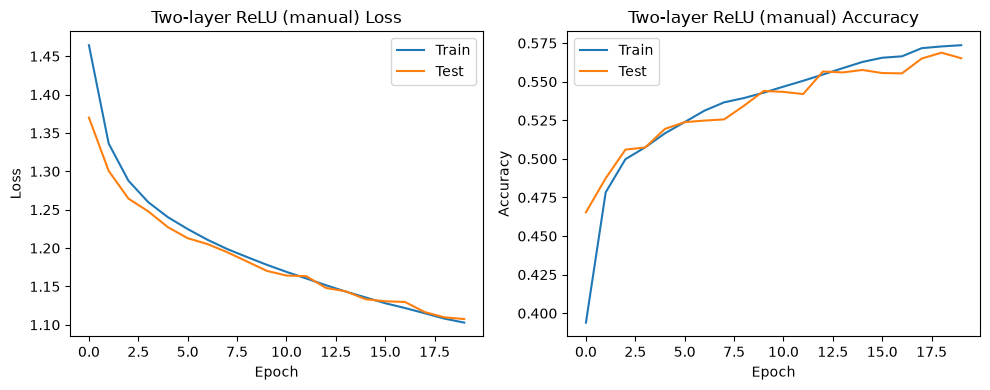

In [86]:
class TwoLayerReLUNet:
    def __init__(self, input_dim, hidden_dim, output_dim):
        self.linear1 = Linear(input_dim, hidden_dim)
        self.act = ReLU()
        self.linear2 = Linear(hidden_dim, output_dim)

    def forward(self, X):
        return self.linear2.forward(self.act.forward(self.linear1.forward(X)))

    def backward(self, dout):
        return self.linear1.backward(self.act.backward(self.linear2.backward(dout)))

class TwoLayerOpt:
    def __init__(self, opt1, opt2):
        self.opt1, self.opt2 = opt1, opt2
    def step(self):
        # HINT
        # ... :)
        self.opt2.step()
        # ... :)
        self.opt1.step()

np.random.seed(0)
net = TwoLayerReLUNet(X_train.shape[1],64, num_classes_to_use)
opt = TwoLayerOpt(OneLayerGD(net.linear1, 1e-3), OneLayerGD(net.linear2, 1e-3))

history_2layer = train(net, CategoricalCrossEntropyLoss(), opt,
                       X_train, y_train_one_hot, X_test, y_test_one_hot,
                       epochs=20, batch_size=32, log_every=5)
plot_history(history_2layer, "Two-layer ReLU (manual)")

### Part 1.7: Multi-Layer Nonlinear Model, or the Multi-Layer Perceptron (MLP)

Now we will go deep by defining multi-layer networks.
For historical reasons, such networks made with linear layers and nonlinearities are called Multi-Layer Perceptrons (MLPs), and in current deep leanring terminology they are also called feedforward networks (FFNs).

In Part 1.4, we trained a single-layer linear classifier:

$$
X
\rightarrow
\text{Linear}(d_{\text{in}}, d_{\text{out}})
\rightarrow
\text{Softmax + CCE},
$$

where $d_{\text{out}}$ is the number of classes.

In 1.4, the classifier only applies a linear transformation before computing the classification loss. In this part, we will study how different nonlinear activation functions from 1.5 affect the model and its optimization behavior.

#### Task 1: Sequential Model and Optimizer

To do that, we need to define a Sequential Model class, which will allow us to make networks that apply each layer in sequence. In our case, the layers are learnable linear layers and nonlinear layers.

In [87]:
class SequentialModel:
    def __init__(self, layers):
        self.layers = layers

    def forward(self, X):
        # TODO
        for layer in self.layers:
            X = layer.forward(X)
        return X

    def backward(self, dout):
        
        # TODO
        for layer in reversed(self.layers):
            dout = layer.backward(dout)
        return dout


And, we need a new GD optimizer class, one that can take in a list layers

In [88]:
class GD:
    def __init__(self, layers, lr):
        self.layers = layers
        self.lr = lr
    def step(self):
        for layer in self.layers:
            for p, g in zip(layer.get_params(), layer.get_grads()):
                p -= self.lr * g

Now that you've installed SequentialModel, you are ready to start training models of many kinds! We will start with two-layer models with different activation functions.


Sigmoid and ReLU preserve the feature dimension, so they can be inserted directly after the linear layer. PN-ReLU behaves differently: it doubles the feature dimension. This will require a small change to the model architecture.

The goal of this part is to gradually modify the classifier and compare how different choices of activation and architecture affect training.

*Hint:*
- use `SequentialModel` to build a model with multiple layers
- use `CategoricalCrossEntropyLoss` as the loss function,
- use `GD` as the optimizer,
- use `train` to train the model,
- use `plot_history` to plot training history,

#### Task 2: Add Sigmoid

First, add a Sigmoid activation after the linear layer.

The architecture becomes:

$$
X
\rightarrow
\text{Linear}(d_{\text{in}}, d_{\text{hidden}})
\rightarrow
\text{Sigmoid}
\rightarrow
\text{Linear}(d_{\text{hidden}}, d_{\text{out}})
\rightarrow
\text{Softmax + CCE}.
$$

Sigmoid preserves the feature dimension, so no additional layer is required.

Complete the forward and backward propagation using your `Sigmoid` implementation, and train the model using the same SGD procedure from Part 1.4.


Untrained   | Train loss: 1.7454, accuracy: 23.13% | Test loss: 1.7472, accuracy: 22.76%
Epoch 10/20 | Train loss: 1.1747, accuracy: 54.14% | Test loss: 1.1697, accuracy: 53.94%
Epoch 20/20 | Train loss: 1.0963, accuracy: 57.14% | Test loss: 1.1047, accuracy: 56.96%


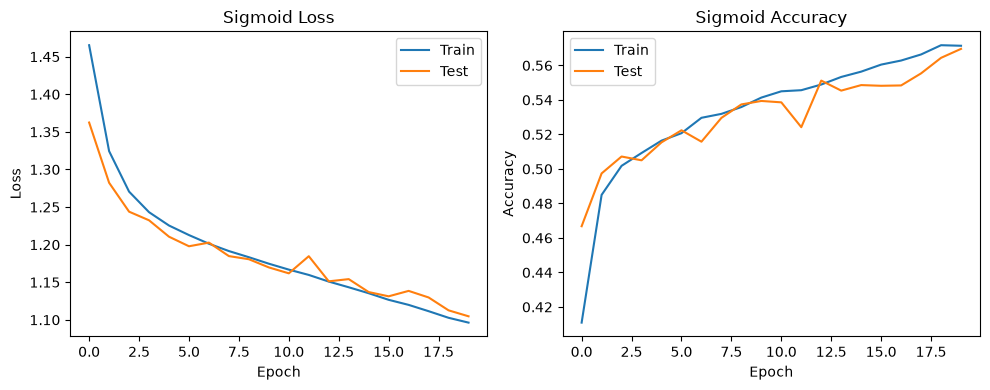

In [89]:
np.random.seed(0)

input_dim = X_train.shape[1]
hidden_dim = 64
output_dim = num_classes_to_use

# TODO: Build the model with:
# Linear(input_dim, hidden_dim) -> Sigmoid() -> ...
model_sigmoid = SequentialModel([
    Linear(input_dim, hidden_dim),
    Sigmoid(),
    Linear(hidden_dim, output_dim)
])

# TODO: Create the categorical cross-entropy loss.
loss_fn = CategoricalCrossEntropyLoss()

# TODO: Create the GD optimizer using model_sigmoid.layers
# with learning rate 0.01.
opt = GD(model_sigmoid.layers, 0.01)

# TODO: Train the model for 20 epochs with batch size 32.
history_sigmoid = train(model_sigmoid, loss_fn, opt, X_train, y_train_one_hot, X_test, y_test_one_hot, 20, 32, log_every=10)

# TODO: Plot the training history with the title "Sigmoid".
plot_history(history_sigmoid, "Sigmoid")

#### Task 3: Replace Sigmoid with ReLU

Next, repeat Task 1 using a ReLU activation instead of Sigmoid.

The architecture becomes:

$$
X
\rightarrow
\text{Linear}(d_{\text{in}}, d_{\text{hidden}})
\rightarrow
\text{ReLU}
\rightarrow
\text{Linear}(d_{\text{hidden}}, d_{\text{out}})
\rightarrow
\text{Softmax + CCE}.
$$

Like Sigmoid, ReLU preserves the feature dimension, so no additional layer is required.

Reuse the same model structure, loss function, optimizer, and training pipeline from Task 1. Only replace the Sigmoid activation with your `ReLU` implementation.

Untrained   | Train loss: 1.6824, accuracy: 21.79% | Test loss: 1.6849, accuracy: 21.78%
Epoch 10/20 | Train loss: 0.9835, accuracy: 61.69% | Test loss: 1.0324, accuracy: 59.44%
Epoch 20/20 | Train loss: 0.8882, accuracy: 65.62% | Test loss: 1.0178, accuracy: 59.40%


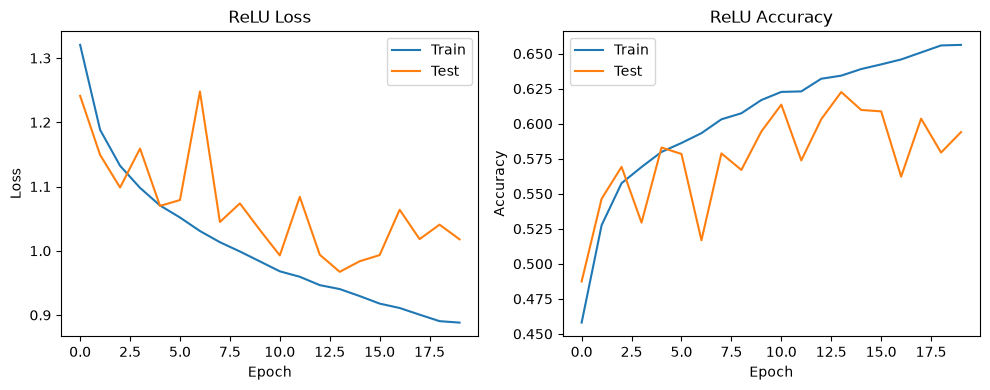

In [90]:
np.random.seed(0)

input_dim = X_train.shape[1]
hidden_dim = 64
output_dim = num_classes_to_use

# TODO: Build the model with:
# Linear(input_dim, hidden_dim) -> ReLU() -> ...
model_relu = SequentialModel([
    Linear(input_dim, hidden_dim),
    ReLU(),
    Linear(hidden_dim, output_dim)
])

# TODO: Create the categorical cross-entropy loss.
loss_fn = CategoricalCrossEntropyLoss()

# TODO: Create the GD optimizer using model_relu.layers
# with learning rate 0.01.
opt = GD(model_relu.layers, 0.01)

# TODO: Train the model for 20 epochs with batch size 32.
history_relu = train(model_relu, loss_fn, opt, X_train, y_train_one_hot, X_test, y_test_one_hot, 20, 32, log_every=10)


# TODO: Plot the training history with the title "ReLU".
plot_history(history_relu, "ReLU")

#### Task 4: Add PN-ReLU

Finally, replace ReLU with PN-ReLU.

Unlike Sigmoid and ReLU, PN-ReLU doubles the feature dimension:

$$
d_{\text{out}} \rightarrow 2d_{\text{out}}.
$$

Therefore, the output of PN-ReLU can no longer be used directly as the class logits. Add a second linear layer to project the doubled representation back to $d_{\text{out}}$ dimensions.

The architecture becomes:

$$
X
\rightarrow
\text{Linear}(d_{\text{in}}, d_{\text{hidden}})
\rightarrow
\text{PN-ReLU}
\rightarrow
\text{Linear}(2d_{\text{hidden}}, d_{\text{out}})
\rightarrow
\text{Softmax + CCE}.
$$

Reuse the same `SequentialModel`, loss function, optimizer, and training pipeline from the previous tasks. This time, make sure both linear layers are included in the model so that their parameters can be updated during training.

Untrained   | Train loss: 1.6350, accuracy: 21.64% | Test loss: 1.6365, accuracy: 22.06%
Epoch 10/20 | Train loss: 0.9421, accuracy: 62.96% | Test loss: 1.0129, accuracy: 59.80%
Epoch 20/20 | Train loss: 0.8361, accuracy: 67.47% | Test loss: 0.9193, accuracy: 63.90%


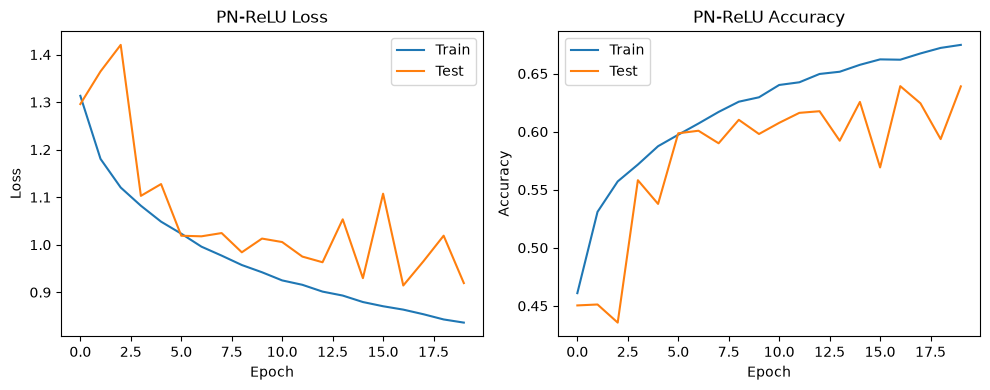

In [91]:
np.random.seed(0)

input_dim = X_train.shape[1]
hidden_dim = 64
output_dim = num_classes_to_use

# TODO: Build the model with:
# Linear(input_dim, hidden_dim)
# -> PNReLU()
# -> ...

model_pnrelu = SequentialModel([
    # TODO
    Linear(input_dim, hidden_dim),
    PNReLU(),
    Linear(hidden_dim*2, output_dim)
])

# TODO: Create the categorical cross-entropy loss.
loss_fn = CategoricalCrossEntropyLoss()

# TODO: Create the GD optimizer using model_pnrelu.layers
# with learning rate 0.01.
opt = GD(model_pnrelu.layers, 0.01)

# TODO: Train the model for 20 epochs with batch size 32.
history_pnrelu = train(model_pnrelu, loss_fn, opt, X_train, y_train_one_hot, X_test, y_test_one_hot, 20, 32, log_every=10)

# TODO: Plot the training history with the title "PN-ReLU".
plot_history(history_pnrelu, "PN-ReLU")

### Part 1.8: Initialization Schemes and Their Impact

Initialization of weights and biases can significantly affect training. In this section, investigate how initialization affects the nonlinear classifier from Part 1.6. Keep the **model structure, loss, optimization procedure, and training settings fixed**, and change only the initialization function.

**Task 1:** Define the two additional initialization functions.

Reuse the previously defined `random_normal_init`. Implement `high_variance_init` and `negative_bias_init` outside the `Linear` class. Each function must accept `(input_dim, output_dim)` and return `(W, b)` with shapes `(input_dim, output_dim)` and `(1, output_dim)`, respectively.

- `high_variance_init`: Sample weights from a standard normal distribution scaled by `10.0`, and set biases to zero.
- `negative_bias_init`: Keep weights (W) initialization the same as `random_normal_init`, but set all biases to `-5.0`.


In [98]:
def high_variance_init(input_dim, output_dim):
    # TODO: Sample W from a standard normal distribution scaled by 10.0.
    # Shape: (input_dim, output_dim)
    W = 10 * np.random.normal(0, 1, (input_dim, output_dim))

    # TODO: Initialize b to zeros with shape (1, output_dim).
    b = np.zeros((1, output_dim))
    return W, b


def negative_bias_init(input_dim, output_dim):
    # Shape: (input_dim, output_dim)
    W = np.random.randn(input_dim, output_dim) / np.sqrt(input_dim)

    # TODO: Initialize b to -5.0 with shape (1, output_dim).
    b = np.zeros((1, output_dim)) - 5
    return W, b


**Task 2:** Compare the provided initialization functions.

In this part, we will compare different initialization methods under different activation functions.

To make these experiments easier to run, first follow the instructions below to create a helper function `train_with_config()`.

The function should build and train a model based on the given initialization function and activation class, then return the training history.

In [99]:
def train_with_config(initialization_fn, activation_cls=PNReLU, lr=0.001,
                      epochs=20, batch_size=32, seed=42, log_every=10, hidden_dim=64):

    # TODO: Set the random seed for reproducibility.
    np.random.seed(seed)

    # TODO: Get input_dim and output_dim.
    input_dim = X_train.shape[1]
    hidden_dim = 64
    output_dim = num_classes_to_use

    # TODO: Create the activation layer.
    activation_layer = activation_cls()

    # TODO:
    # PNReLU doubles the width, while ReLU and Sigmoid preserve it.
    # Therefore, PNReLU uses a hidden factor of 2, while other activations use 1.
    # Infer the hidden_factor of the activation using a dummy input.
    hidden_factor = activation_layer.forward(np.ones((1, 1))).shape[1]

    # TODO:
    # Build the model:
    #
    # Linear(input_dim, hidden_dim)
    # -> activation
    # -> Linear(hidden_factor * hidden_dim, output_dim)
    #
    # Use initialization_fn for BOTH Linear layers.
    model = SequentialModel([
        Linear(input_dim, hidden_dim, initialization_fn),
        activation_layer,
        Linear(hidden_factor * hidden_dim, output_dim, initialization_fn)
    ])

    # TODO: Create the categorical cross-entropy loss.
    loss_fn = CategoricalCrossEntropyLoss()

    # TODO: Create the GD optimizer using model.layers and lr.
    opt = GD(model.layers, lr)

    # TODO:
    # Print the initialization and activation being tested.
    # Hint: use initialization_fn.__name__ and activation_cls.__name__.
    print(f"Testing {initialization_fn.__name__} with {activation_cls.__name__}")

    # TODO:
    # Train the model using the existing train() function
    # and return the training history.
    hist = train(model, loss_fn, opt, X_train, y_train_one_hot, X_test, y_test_one_hot, epochs, batch_size, log_every=log_every)
    return hist


After implementing `train_with_config()`, run all **9 combinations** of:

- 3 activation functions: `Sigmoid`, `ReLU`, and `PNReLU`
- 3 initialization methods: `random_normal_init`, `high_variance_init`, and `negative_bias_init`

For each combination:

1. Train the model using `train_with_config()`.
2. Print the initialization method and activation function being tested.
3. Store the returned training history.
4. Plot the training and test curves so that you can compare how different initialization methods affect each activation function.

Organize your results by activation function, for example:



Testing random_normal_init with Sigmoid
Untrained   | Train loss: 1.6659, accuracy: 20.70% | Test loss: 1.6672, accuracy: 20.32%
Epoch 10/20 | Train loss: 1.3854, accuracy: 47.47% | Test loss: 1.3707, accuracy: 47.36%
Epoch 20/20 | Train loss: 1.2999, accuracy: 49.97% | Test loss: 1.2891, accuracy: 49.24%
Testing high_variance_init with Sigmoid
Untrained   | Train loss: 68.3484, accuracy: 20.98% | Test loss: 68.2013, accuracy: 21.04%
Epoch 10/20 | Train loss: 24.7278, accuracy: 23.82% | Test loss: 24.5335, accuracy: 24.38%
Epoch 20/20 | Train loss: 21.2527, accuracy: 25.66% | Test loss: 21.2056, accuracy: 26.00%
Testing negative_bias_init with Sigmoid
Untrained   | Train loss: 1.6094, accuracy: 20.28% | Test loss: 1.6094, accuracy: 20.10%
Epoch 10/20 | Train loss: 1.5885, accuracy: 25.04% | Test loss: 1.5829, accuracy: 25.60%
Epoch 20/20 | Train loss: 1.5346, accuracy: 35.85% | Test loss: 1.5259, accuracy: 36.62%
Testing random_normal_init with ReLU
Untrained   | Train loss: 1.6497, ac

/var/folders/_v/skb69_hd7ws38n9wgw27djfc0000gn/T/ipykernel_22446/3523552715.py:27: RuntimeWarning: divide by zero encountered in log
  loss = -1 / batch_size * np.sum(np.sum(self.y_true*np.log(self.y_pred_softmax)))
/var/folders/_v/skb69_hd7ws38n9wgw27djfc0000gn/T/ipykernel_22446/3523552715.py:27: RuntimeWarning: invalid value encountered in multiply
  loss = -1 / batch_size * np.sum(np.sum(self.y_true*np.log(self.y_pred_softmax)))


Epoch 10/20 | Train loss: nan, accuracy: 31.27% | Test loss: nan, accuracy: 22.96%
Epoch 20/20 | Train loss: nan, accuracy: 30.74% | Test loss: nan, accuracy: 28.78%
Testing negative_bias_init with ReLU
Untrained   | Train loss: 1.6094, accuracy: 20.00% | Test loss: 1.6094, accuracy: 20.00%
Epoch 10/20 | Train loss: 1.6095, accuracy: 19.45% | Test loss: 1.6094, accuracy: 20.00%
Epoch 20/20 | Train loss: 1.6095, accuracy: 19.26% | Test loss: 1.6094, accuracy: 20.00%
Testing random_normal_init with PNReLU
Untrained   | Train loss: 1.6588, accuracy: 20.04% | Test loss: 1.6631, accuracy: 20.08%
Epoch 10/20 | Train loss: 1.1989, accuracy: 53.62% | Test loss: 1.1933, accuracy: 52.92%
Epoch 20/20 | Train loss: 1.1191, accuracy: 56.94% | Test loss: 1.1179, accuracy: 56.34%
Testing high_variance_init with PNReLU
Untrained   | Train loss: nan, accuracy: 20.04% | Test loss: nan, accuracy: 20.08%
Epoch 10/20 | Train loss: nan, accuracy: 39.82% | Test loss: nan, accuracy: 32.76%
Epoch 20/20 | Train

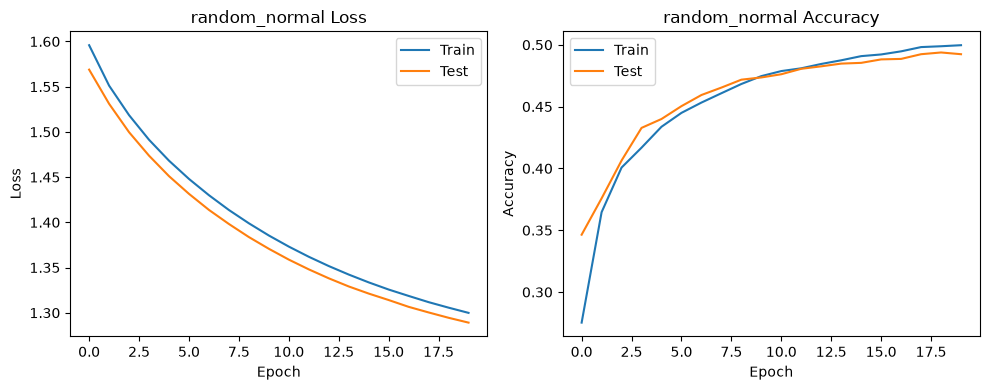

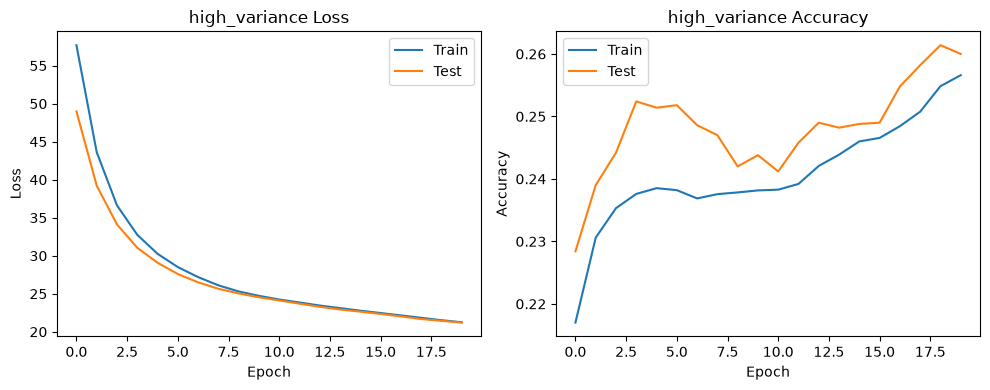

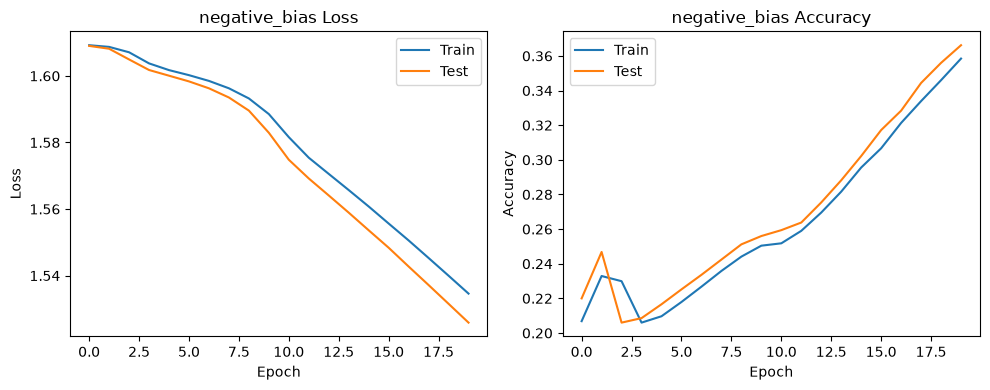

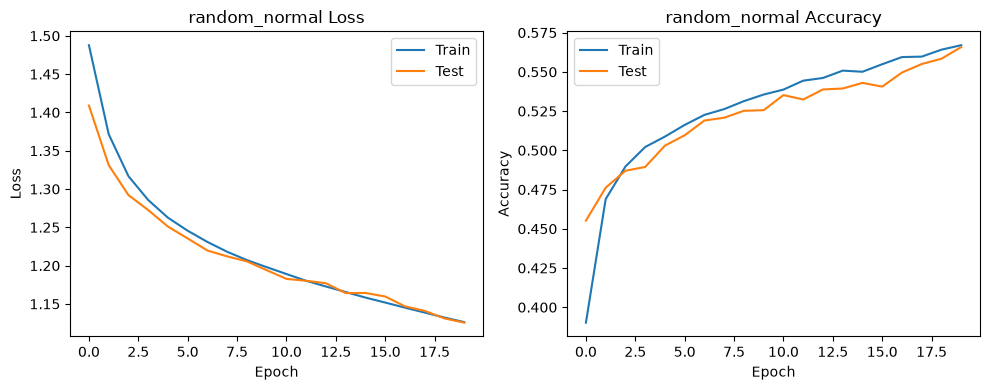

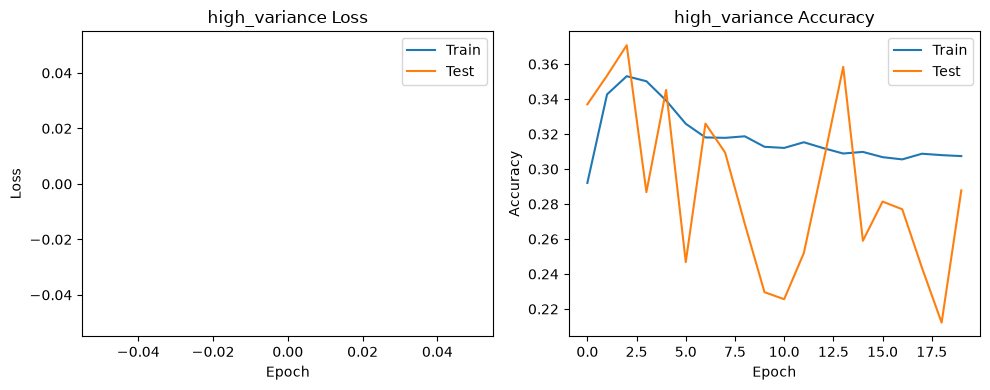

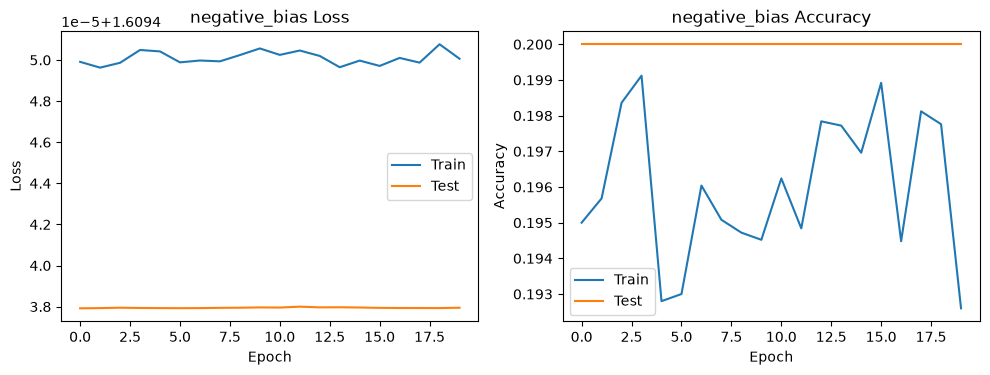

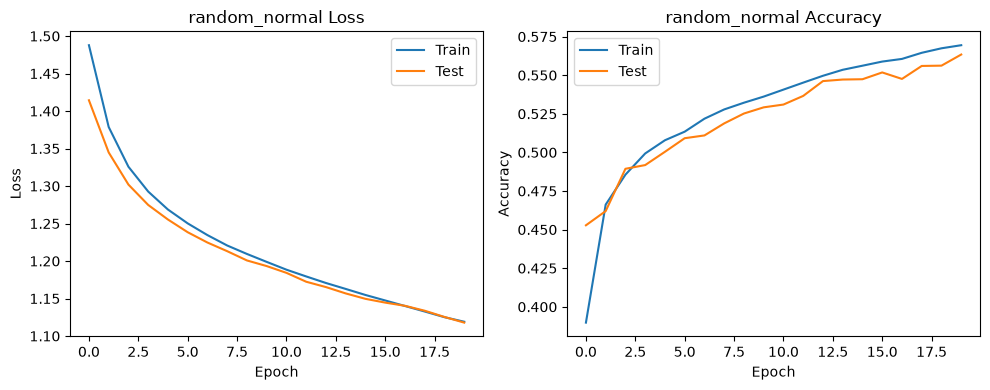

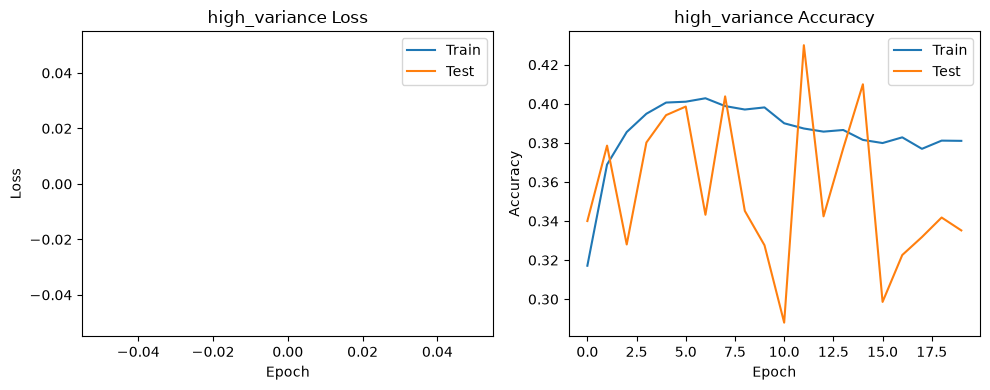

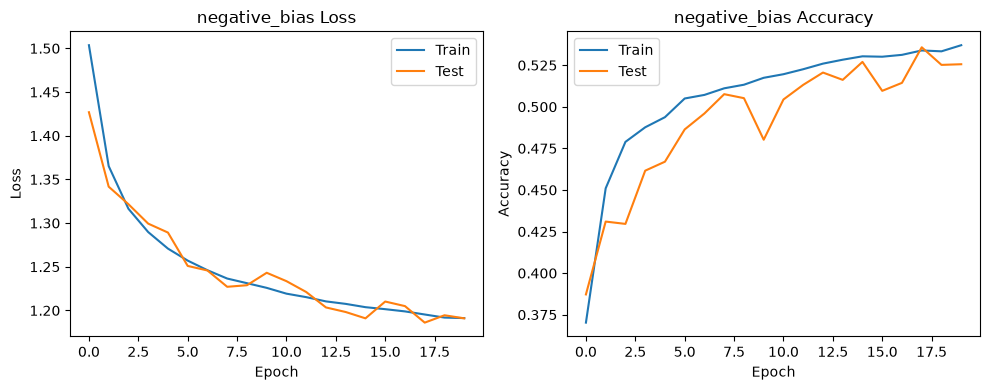

In [100]:
# TODO: Run all three initialization methods with Sigmoid.
histories_Sigmoid = {
    "random_normal": train_with_config(random_normal_init, Sigmoid),
    "high_variance": train_with_config(high_variance_init, Sigmoid),
    "negative_bias": train_with_config(negative_bias_init, Sigmoid),
}

# TODO: Run all three initialization methods with ReLU.
histories_ReLU = {
    "random_normal": train_with_config(random_normal_init, ReLU),
    "high_variance": train_with_config(high_variance_init, ReLU),
    "negative_bias": train_with_config(negative_bias_init, ReLU),
}

# TODO: Run all three initialization methods with PNReLU.
histories_PNReLU = {
    "random_normal": train_with_config(random_normal_init, PNReLU),
    "high_variance": train_with_config(high_variance_init, PNReLU),
    "negative_bias": train_with_config(negative_bias_init, PNReLU),
}

# TODO:
# Plot the histories for all 9 combinations.
#
# For each activation function, compare the three initialization methods
# using their training/test loss and accuracy curves.
for name, hist in histories_Sigmoid.items():
    plot_history(hist, name)

for name, hist in histories_ReLU.items():
    plot_history(hist, name)

for name, hist in histories_PNReLU.items():
    plot_history(hist, name)


#### Discussion on Initialization and Activation Functions (Your Answer Here)

Compare the training curves across all **9 activation–initialization combinations** and briefly discuss:

- **Sigmoid** with each initialization method
- **ReLU** with each initialization method
- **PN-ReLU** with each initialization method

In your discussion, consider:

- Which combinations trained successfully?
- Which combinations trained poorly or failed to optimize?
- How did the initialization method affect each activation function differently?
- What behavior in the loss and accuracy curves supports your explanation?

## **TODO!**

### Part 1.9: Visualizing Training Losses with TensorBoard

TensorBoard can also be used with our NumPy implementation. In this part, we show an example of how TensorBoard can help us visualize the initialization-activation sweep we just ran.


In [102]:
# TODO: Uncomment these lines when running in Colab.
all_histories = {
    "PNReLU":  histories_PNReLU,
    "ReLU":    histories_ReLU,
    "Sigmoid": histories_Sigmoid,
}

def log_history_to_tensorboard(history, log_dir):
    writer = tf.summary.create_file_writer(log_dir)
    with writer.as_default():
        for epoch in range(len(history["train_loss"])):
            for name, values in history.items():
                tf.summary.scalar(name, values[epoch], step=epoch + 1)
    writer.close()

sweep_dir = "logs/sweep"

for act, hs in all_histories.items():
    for init, h in hs.items():
        log_history_to_tensorboard(h, f"{sweep_dir}/{init}-{act}")

%tensorboard --logdir {sweep_dir}

Reusing TensorBoard on port 6006 (pid 22818), started 0:00:29 ago. (Use '!kill 22818' to kill it.)

---


## Problem 2: NumPy - Multi-layer Network


In Problem 1, you implemented the components needed to construct and train
multi-layer deep networks:

`Linear`, activation layers, `SequentialModel`, `GD`, the loss function,
and the training loop.

In this problem, you will reuse those components to investigate how
**network depth**, **activation functions**, and **initialization** affect
optimization and performance.

You should not implement new forward/backward logic or a new optimizer in
this problem.

### Part 2.1: Depth vs. Performance

We will first investigate the effect of increasing network depth.

Complete `build_deep_model()` using the `Linear`, `ReLU`, and
`SequentialModel` components from Problem 1.

Then compare:

- a network with **1 hidden layers**
- a network with **3 hidden layers**

Keep the hidden dimension, activation function, initialization, learning
rate, and training procedure fixed.

Use:

- `ReLU` activation,
- `random_normal_init`,
- hidden dimension 64.

Compare the training and test loss/accuracy curves and briefly discuss
whether increasing depth improves performance.

In [157]:
input_dim = X_train.shape[1]
hidden_dim = 64
output_dim = num_classes_to_use

part2_learning_rate = 0.001
part2_epochs = 20
part2_batch_size = 32


def build_deep_model(
    num_hidden_layers,
    activation_cls,
    hidden_initialization_fn=random_normal_init,
    output_initialization_fn=random_normal_init,
):
    """

    Each hidden layer:
        Linear -> Activation

    Final layer:
        Linear -> logits
    """

    layers = []

    # -------------------------------------------------------
    # TODO 1:
    # Add the first hidden layer:
    #
    # input_dim -> hidden_dim -> activation
    # -------------------------------------------------------
    layers.append(Linear(input_dim, hidden_dim, hidden_initialization_fn))
    layers.append(activation_cls())

    # -------------------------------------------------------
    # TODO 2:
    # Add the remaining hidden layers:
    #
    # hidden_dim -> hidden_dim -> activation
    # -------------------------------------------------------
    for _ in range(num_hidden_layers-1):
        layers.append(Linear(hidden_dim, hidden_dim, hidden_initialization_fn))
        layers.append(activation_cls())

    # -------------------------------------------------------
    # TODO 3:
    # Add the output layer:
    #
    # hidden_dim -> output_dim
    #
    # Do not add an activation after the output layer.
    # CategoricalCrossEntropyLoss expects logits.
    # -------------------------------------------------------
    layers.append(Linear(hidden_dim, output_dim, output_initialization_fn))

    return SequentialModel(layers)

In [158]:
# Quick validation before doing the longer training runs

test_model = build_deep_model(
    num_hidden_layers=2,
    activation_cls=ReLU
)

test_logits = test_model.forward(X_train[:4])

assert test_logits.shape == (4, output_dim)

# Linear -> ReLU -> Linear -> ReLU -> Linear
assert len(test_model.layers) == 5

print("Part 2.1 model-construction check passed!")
print("Output shape:", test_logits.shape)

Part 2.1 model-construction check passed!
Output shape: (4, 5)


Next, we will study how increasing the number of hidden layers affects optimization.

**Task 2:** Complete the function below. We will reuse it to run the depth experiments in the next task.


In [159]:
def run_depth_experiment(
    num_hidden_layers,
    model_name,
    seed=0
):
    # TODO: Set the random seed for reproducibility.
    np.random.seed(seed)

    # TODO:
    # Build the model using build_deep_model() with:
    # - num_hidden_layers
    # - ReLU activation
    # - random_normal_init for hidden layers
    # - random_normal_init for the output layer
    model = build_deep_model(num_hidden_layers, ReLU, random_normal_init, random_normal_init)

    # TODO: Create the categorical cross-entropy loss.
    loss_fn = CategoricalCrossEntropyLoss()

    # TODO:
    # Create the GD optimizer using model.layers and
    # part2_learning_rate.
    opt = GD(model.layers, part2_learning_rate)

    print(
        f"\n--- Training {model_name} "
        f"({num_hidden_layers} hidden layer(s)) ---"
    )

    # TODO:
    # Train the model using the train() function from Problem 1.
    # Use:
    # - epochs=part2_epochs
    # - batch_size=part2_batch_size
    # - log_every=10
    history = train(model, loss_fn, opt, X_train, y_train_one_hot, X_test, y_test_one_hot, part2_epochs, part2_batch_size, log_every=10)

    # TODO: Return the training history.
    return history



In [160]:
histories_depth = {}

histories_depth["1 Hidden Layer"] = run_depth_experiment(
    num_hidden_layers=1,
    model_name="1 Hidden Layer",
    seed=0
)

histories_depth["3 Hidden Layers"] = run_depth_experiment(
    num_hidden_layers=3,
    model_name="3 Hidden Layers",
    seed=0
)



--- Training 1 Hidden Layer (1 hidden layer(s)) ---
Untrained   | Train loss: 1.6824, accuracy: 21.79% | Test loss: 1.6849, accuracy: 21.78%
Epoch 10/20 | Train loss: 1.1783, accuracy: 54.29% | Test loss: 1.1703, accuracy: 54.40%
Epoch 20/20 | Train loss: 1.1029, accuracy: 57.36% | Test loss: 1.1075, accuracy: 56.52%

--- Training 3 Hidden Layers (3 hidden layer(s)) ---
Untrained   | Train loss: 1.6437, accuracy: 19.06% | Test loss: 1.6423, accuracy: 19.18%
Epoch 10/20 | Train loss: 1.2000, accuracy: 52.53% | Test loss: 1.1893, accuracy: 52.40%
Epoch 20/20 | Train loss: 1.1066, accuracy: 56.51% | Test loss: 1.1054, accuracy: 55.70%



**Task 3:** Finally we would plot the history for the deep model

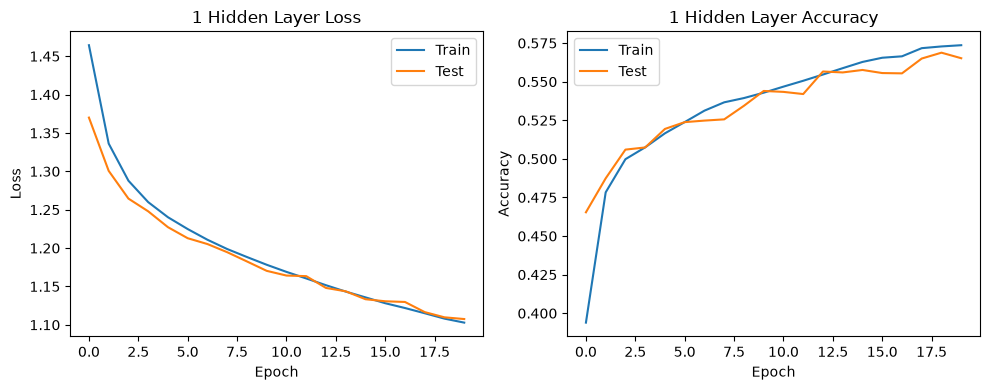

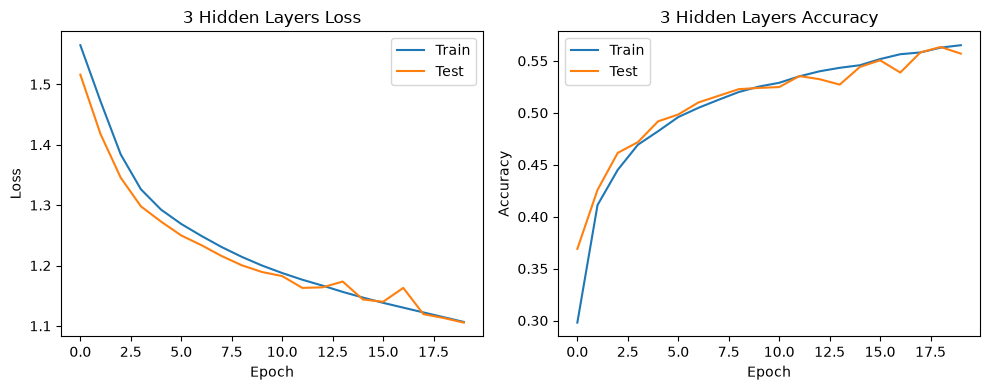

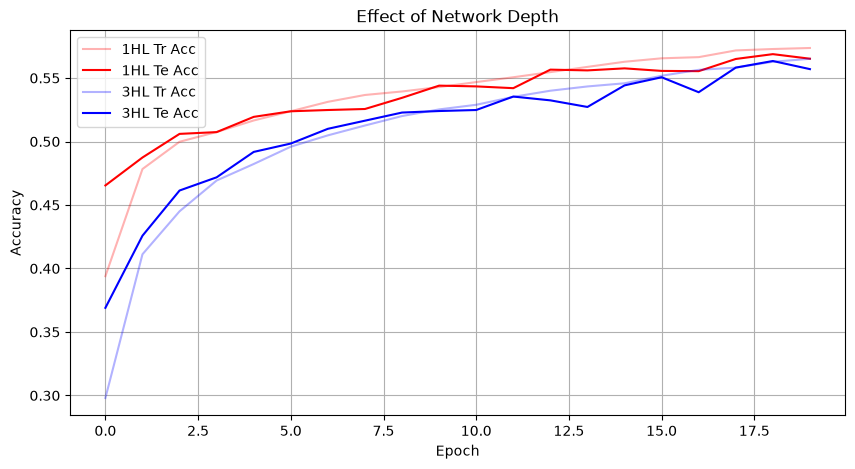

In [161]:
# TODO: Reuse plot_history() to plot the history for the 1-hidden-layer model.
plot_history(histories_depth["1 Hidden Layer"], "1 Hidden Layer")
# TODO: Reuse plot_history() to plot the history for the 3-hidden-layer model.
plot_history(histories_depth["3 Hidden Layers"], "3 Hidden Layers")


# Plot training and test accuracy on the same axes to compare the effect of network depth
plt.figure(figsize=(10, 5))

plt.plot(histories_depth["1 Hidden Layer"]["train_acc"],'r',alpha=0.3, label="1HL Tr Acc")
plt.plot(histories_depth["1 Hidden Layer"]["test_acc"],'r', label="1HL Te Acc")
plt.plot(histories_depth["3 Hidden Layers"]["train_acc"],'b',alpha=0.3, label="3HL Tr Acc")
plt.plot(histories_depth["3 Hidden Layers"]["test_acc"],'b', label="3HL Te Acc")


plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Effect of Network Depth")
plt.legend()
plt.grid(True)
plt.show()

#### Discussion (Your Answer Here)

1. How does the deeper model compare with the shallower model in terms of
   training loss and accuracy?

2. Does increasing depth necessarily improve test accuracy?

3. What factors might make the deeper model harder to optimize?

### Part 2.2: Interaction Between Initialization and Activation Functions

In Part 2.1, you changed network depth while keeping the other settings
fixed.

Now we will keep the architecture fixed and investigate how the choice of
**activation function interacts with initialization**.

We provide a fixed initialization function, `high_gain_init()`. You do not
need to modify this function.

Construct two networks with **5 hidden layers**:

- one using `Sigmoid`,
- one using `ReLU`.

Both networks should use exactly the same initialization function,
architecture, random seed, learning rate, and training procedure.

Before training, inspect the provided layer-by-layer activation statistics.

Then train both models and compare their loss and accuracy curves.

Briefly explain why the two activation functions behave differently under
the same initialization.

#### Provided initialization

In [183]:
def high_gain_init(input_dim, output_dim):
    """
    Initialization used only for the Part 2.2 experiment.

    W ~ Normal(0, 2.5^2 / fan_in)
    b = 0

    This is intentionally aggressive so that the interaction
    between activation function, initialization, and depth
    becomes easier to observe.
    """

    gain = 2.5

    W = (
        np.random.randn(input_dim, output_dim)
        * gain
        / np.sqrt(input_dim)
    )

    b = np.zeros((1, output_dim))

    return W, b

#### Provided diagnostic helpers

In [184]:
def collect_activation_statistics(model, X):
    """
    Run a forward pass and collect statistics after
    each hidden activation layer.
    """

    out = X
    stats = []

    hidden_layer_index = 0

    for layer in model.layers:

        out = layer.forward(out)

        if isinstance(layer, (Sigmoid, ReLU)):

            hidden_layer_index += 1

            stats.append({
                "layer": hidden_layer_index,
                "mean": np.mean(out),
                "std": np.std(out),
                "max_abs": np.max(np.abs(out)),
                "zero_fraction": np.mean(out == 0)
            })

    return stats


def print_activation_statistics(name, stats):

    print(f"\n{name}")

    print(
        f"{'Layer':>6} "
        f"{'Mean':>12} "
        f"{'Std':>12} "
        f"{'Max |a|':>12} "
        f"{'Zero frac.':>12}"
    )

    for s in stats:

        print(
            f"{s['layer']:>6d} "
            f"{s['mean']:>12.4f} "
            f"{s['std']:>12.4f} "
            f"{s['max_abs']:>12.4f} "
            f"{s['zero_fraction']:>12.4f}"
        )


**Task 1:** Build the two models

In [191]:
experiment_depth = 5
experiment_seed = 0

# -------------------------------------------------------
# TODO: Sigmoid network, use build_deep_model() from Part 2.1
# -------------------------------------------------------
sigmoid_probe_model = build_deep_model(experiment_depth, Sigmoid, high_gain_init, high_gain_init)


# -------------------------------------------------------
# ReLU network, use build_deep_model() from Part 2.1
# -------------------------------------------------------
relu_probe_model = build_deep_model(experiment_depth, ReLU, high_gain_init, high_gain_init)



**Task 2:** Inspect activation

In [192]:
X_probe = X_train[:256]


sigmoid_stats = collect_activation_statistics(
    sigmoid_probe_model,
    X_probe
)

relu_stats = collect_activation_statistics(
    relu_probe_model,
    X_probe
)


print_activation_statistics(
    "Sigmoid activation statistics",
    sigmoid_stats
)

print_activation_statistics(
    "ReLU activation statistics",
    relu_stats
)


Sigmoid activation statistics
 Layer         Mean          Std      Max |a|   Zero frac.
     1       0.4993       0.2511       0.9975       0.0000
     2       0.5244       0.2555       0.9796       0.0000
     3       0.5043       0.2778       0.9937       0.0000
     4       0.5440       0.2542       0.9797       0.0000
     5       0.4952       0.2899       0.9533       0.0000

ReLU activation statistics
 Layer         Mean          Std      Max |a|   Zero frac.
     1       0.4706       0.7466       5.8046       0.4951
     2       0.6928       1.0736       8.0369       0.5012
     3       1.1472       1.8292      12.4997       0.5450
     4       1.8979       2.7464      18.2449       0.4910
     5       3.3226       5.0739      41.2714       0.4976



**Task 3:** Train the two models

In [194]:
activation_experiment_epochs = 20


def run_activation_experiment(
    activation_cls,
    model_name,
    seed=0
):

    # TODO: Set the random seed for reproducibility.
    np.random.seed(seed)
    # TODO:
    # Build the model using build_deep_model() with:
    model = build_deep_model(experiment_depth, activation_cls, high_gain_init, high_gain_init)
    # TODO: Create the categorical cross-entropy loss.
    loss_fn = CategoricalCrossEntropyLoss()

    # TODO:
    # Create the GD optimizer using model.layers and
    # part2_learning_rate.
    opt = GD(model.layers, part2_learning_rate)


    print(
        f"\n--- Training {model_name} "
        f"({experiment_depth} hidden layers) ---"
    )
    # TODO:
    # Train the model using the train() function from Problem 1.

    history = train(model, loss_fn, opt, X_train, y_train_one_hot, X_test, y_test_one_hot, activation_experiment_epochs, 32)

    return history

In [195]:
histories_activation = {}

histories_activation["Sigmoid"] = run_activation_experiment(
    Sigmoid,
    "Sigmoid + High Gain",
    seed=experiment_seed
)

histories_activation["ReLU"] = run_activation_experiment(
    ReLU,
    "ReLU + High Gain",
    seed=experiment_seed
)


--- Training Sigmoid + High Gain (5 hidden layers) ---
Untrained   | Train loss: 2.2809, accuracy: 19.99% | Test loss: 2.2810, accuracy: 20.00%
Epoch 01/20 | Train loss: 1.7846, accuracy: 19.39% | Test loss: 1.6136, accuracy: 15.82%
Epoch 02/20 | Train loss: 1.6104, accuracy: 18.17% | Test loss: 1.6091, accuracy: 19.12%
Epoch 03/20 | Train loss: 1.6091, accuracy: 19.68% | Test loss: 1.6081, accuracy: 24.24%
Epoch 04/20 | Train loss: 1.6081, accuracy: 23.18% | Test loss: 1.6072, accuracy: 22.36%
Epoch 05/20 | Train loss: 1.6071, accuracy: 22.40% | Test loss: 1.6063, accuracy: 25.44%
Epoch 06/20 | Train loss: 1.6063, accuracy: 23.99% | Test loss: 1.6054, accuracy: 26.36%
Epoch 07/20 | Train loss: 1.6055, accuracy: 26.61% | Test loss: 1.6044, accuracy: 29.36%
Epoch 08/20 | Train loss: 1.6045, accuracy: 27.16% | Test loss: 1.6034, accuracy: 31.46%
Epoch 09/20 | Train loss: 1.6037, accuracy: 28.80% | Test loss: 1.6025, accuracy: 30.82%
Epoch 10/20 | Train loss: 1.6026, accuracy: 29.71% | T

**Task 4:** Plot the history

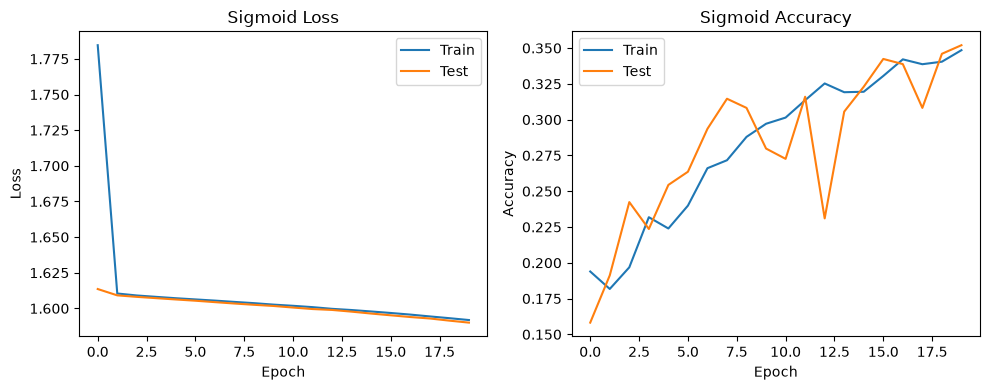

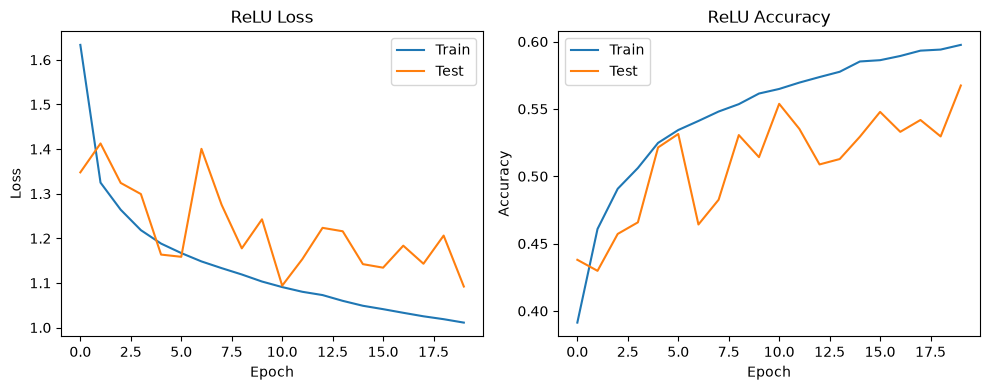

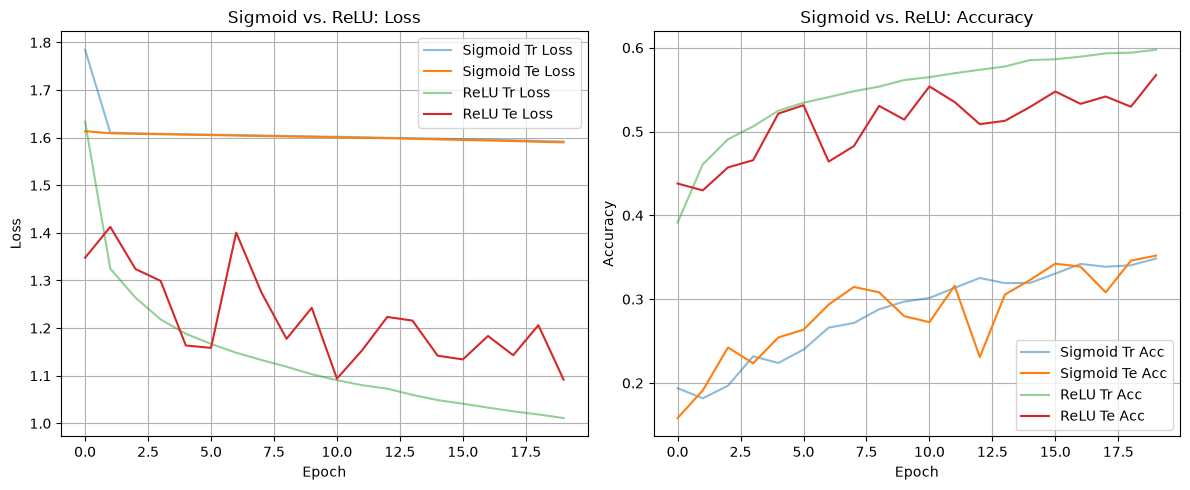

In [196]:
# TODO: Reuse plot_history() to plot the history for the Sigmoid and ReLU model.
plot_history(histories_activation["Sigmoid"], "Sigmoid")
plot_history(histories_activation["ReLU"], "ReLU")

# Compare Sigmoid and ReLU training/test loss and accuracy

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

for name, history in histories_activation.items():
    #TODO: Plot training and testing loss
    plt.plot(history["train_loss"], label=f'{name} Tr Loss', alpha = 0.5)
    plt.plot(history["test_loss"], label=f'{name} Te Loss')
    


plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Sigmoid vs. ReLU: Loss")
plt.legend()
plt.grid(True)


# Accuracy
plt.subplot(1, 2, 2)

for name, history in histories_activation.items():
    #TODO: Plot training and testing Acc
    plt.plot(history["train_acc"], label=f'{name} Tr Acc', alpha = 0.5)
    plt.plot(history["test_acc"], label=f'{name} Te Acc')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Sigmoid vs. ReLU: Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

#### Discussion (Your Answer Here)

1. **Sigmoid:** How do the activation statistics change as depth increases?

2. **ReLU:** How do the activation statistics change as depth increases?

3. **Training behavior:** How do the loss and accuracy curves differ?

4. **Explanation:** Why does the same initialization lead to different
   behavior for Sigmoid and ReLU?

In your explanation, consider bounded vs. unbounded activations,
saturation, zero activations, and how activation magnitude changes with
depth.

### Part 2.3: Visualize the Experiments with TensorBoard

Reuse the TensorBoard logging helper from Problem 1 to visualize the
experiments from Parts 2.1 and 2.2.

Compare:

- the shallow and deep ReLU networks from Part 2.1;
- the Sigmoid and ReLU networks from Part 2.2.

Use TensorBoard to compare training/test loss and accuracy.

In [197]:
part2_log_dir = "logs/part2"


# Depth experiments
for name, history in histories_depth.items():

    log_history_to_tensorboard(
        history,
        f"{part2_log_dir}/depth/{name.replace(' ', '_')}"
    )


# Activation experiments
for name, history in histories_activation.items():

    log_history_to_tensorboard(
        history,
        f"{part2_log_dir}/activation/{name.replace(' ', '_')}"
    )

In [199]:
%tensorboard --logdir logs

Reusing TensorBoard on port 6007 (pid 23737), started 0:00:06 ago. (Use '!kill 23737' to kill it.)

---


## Problem 3: PyTorch


In this final problem, you will switch to PyTorch, a popular deep learning framework. You will reimplement the nonlinear model from Problem 1, verify its performance, and compare training speeds between CPU and GPU.


### Part 3.1: Enabling GPU in Colab and Device Management

PyTorch makes it easy to leverage GPUs for accelerated computation. In Google Colab, you can enable a GPU runtime.

**Task:**
1.  Go to `Runtime > Change runtime type` in the Colab menu.
2.  Select `T4 GPU` as the hardware accelerator and save.
3.  Run the code cell below to verify GPU availability and move tensors/models to the selected device, no edit needed.


In [204]:
import torch
import torch.nn as nn
import torch.optim as optim
import time

print("PyTorch libraries loaded successfully.")

# Check for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Example: move a tensor to the device
x_cpu = torch.randn(3, 3)
print(f"Tensor on CPU:\n{x_cpu}")
x_gpu = x_cpu.to(device)
print(f"Tensor on {device}:\n{x_gpu}")

# Example: move a simple model to the device
class SimpleModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(10, 1)

    def forward(self, x):
        return self.linear(x)

model_cpu = SimpleModel()
print(f"Model on CPU:\n{model_cpu}")
model_gpu = SimpleModel().to(device)
print(f"Model on {device}:\n{model_gpu}")

PyTorch libraries loaded successfully.
Using device: cpu
Tensor on CPU:
tensor([[ 0.4610, -0.4252, -0.4926],
        [-0.3874,  0.1022,  0.6256],
        [-0.4416, -0.0799, -0.5118]])
Tensor on cpu:
tensor([[ 0.4610, -0.4252, -0.4926],
        [-0.3874,  0.1022,  0.6256],
        [-0.4416, -0.0799, -0.5118]])
Model on CPU:
SimpleModel(
  (linear): Linear(in_features=10, out_features=1, bias=True)
)
Model on cpu:
SimpleModel(
  (linear): Linear(in_features=10, out_features=1, bias=True)
)


You will notice that in this example above, the Simple Model is inheriting from the class `nn.Module`.

This is the base class for all deep network modules in PyTorch, so every layer/losses/full network you build in PyTorch should be a subclass of `nn.Module`.

Now, just to convince you that gpu is indeed faster at matrix multiplication, let's try one:

In [205]:
a_cpu, b_cpu = torch.randn(1024, 4096), torch.randn(4096, 1024)
a_gpu, b_gpu = a_cpu.cuda(), b_cpu.cuda()

def bench(a, b, iters=20, sync=lambda: None):
    a @ b; sync()                     # warmup
    start = time.perf_counter()
    for _ in range(iters):
        a @ b
    sync()                            # wait for the GPU to actually finish
    return (time.perf_counter() - start) / iters

t_cpu = bench(a_cpu, b_cpu)
t_gpu = bench(a_gpu, b_gpu, sync=torch.cuda.synchronize)

print(f"CPU: {t_cpu*1e3:.1f} ms per matmul")
print(f"GPU: {t_gpu*1e3:.1f} ms per matmul")
print(f"GPU is {t_cpu/t_gpu:.0f}x faster")

AssertionError: Torch not compiled with CUDA enabled

### Part 3.2: Reimplementing the Nonlinear Model from Problem 1 using PyTorch

You will now reimplement the `Linear -> PN-ReLU -> Linear` model from Problem 1 using PyTorch's `nn.Module` and `nn.functional` components. This will give you a taste of how deep learning frameworks streamline model development.


In [ ]:
# Data Loading: creating torch tensors from numpy ndarray
# Read, but DO NOT EDIT This Cell

# Convert NumPy data to PyTorch tensors
X_train_torch = torch.from_numpy(X_train).float()
y_train_torch = torch.from_numpy(y_train).long() # Use long() for CrossEntropyLoss
X_test_torch = torch.from_numpy(X_test).float()
y_test_torch = torch.from_numpy(y_test).long()

# Initialize loss, and optimizer
input_features = X_train_torch.shape[1]
hidden_features_1 = 10
output_features = num_classes_to_use # Changed for multi-class

loss_fn = nn.CrossEntropyLoss() # Changed to CrossEntropyLoss for multi-class with logits

epochs_pt = 100
batch_size_pt = 32


**Task:**
1.  Create a PyTorch model class for the `Linear -> PN-ReLU -> Linear` architecture.
2.  Implement a training loop using PyTorch's optimizers and loss functions.
3.  Train the model and verify that it achieves similar performance to your NumPy implementation.


In [ ]:
# Task 1: PyTorch equivalent of PN-ReLU
class PyTorchPNReLU(nn.Module):
    def forward(self, x):
        # Hint: your implementation should use torch.relu
        raise NotImplementedError()

class PyTorchModel(nn.Module):
    def __init__(self, input_dim, hidden_dim_1, output_dim):
        super().__init__()
        raise NotImplementedError()

    def forward(self, x):
        raise NotImplementedError()
        return x # Return logits

# Now we can initialize this model implemented with PyTorch
model_pt = PyTorchModel(input_features, hidden_features_1, output_features).to(device)
optimizer = optim.SGD(model_pt.parameters(), lr=0.01)

In [ ]:
def train_step(model, optimizer, loss_fn, inputs, labels):
    """One optimizer update on one batch.

    Returns:
        loss_sum:  batch loss * batch size (0-d tensor, detached from the graph)
        n_correct: number of correct predictions in the batch (0-d tensor)
    """
    model.train()

    # TODO: Forward pass, then compute the loss
    raise NotImplementedError()
    # outputs =
    # loss =

    # TODO: Zero the gradients, backpropagate, and take an optimizer step
    # Hint: https://docs.pytorch.org/docs/2.14/optim.html#taking-an-optimization-step
    raise NotImplementedError()

    n_correct = (outputs.argmax(dim=1) == labels).sum()
    return loss.detach() * inputs.size(0), n_correct


@torch.no_grad()
def eval_step(model, loss_fn, inputs, labels):
    """Forward pass only. Same return convention as train_step."""
    model.eval()

    # TODO: Forward pass and loss. No optimizer or backward call is needed here.
    raise NotImplementedError()
    # outputs =
    # loss =

    # TODO: Count correct predictions (same idea as in train_step)
    raise NotImplementedError()
    # n_correct =

    return loss * inputs.size(0), n_correct


def train(model, optimizer, loss_fn, X_train, y_train, X_test, y_test,
          epochs, batch_size, device="cuda", log_every=10):
    # Move data to the device once, and fix label shape once
    X_train, y_train = X_train.to(device), y_train.view(-1).to(device)
    X_test, y_test = X_test.to(device), y_test.view(-1).to(device)
    n_train, n_test = X_train.size(0), X_test.size(0)

    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

    for epoch in range(epochs):
        perm = torch.randperm(n_train, device=device)   # new shuffle every epoch
        loss_sum = torch.zeros((), device=device)
        correct = torch.zeros((), device=device)

        for i in range(0, n_train, batch_size):
            # TODO: Take this batch's indices from `perm`, index X_train / y_train with them,
            # and call train_step. Note the last batch may be smaller than batch_size.
            raise NotImplementedError()
            # idx =
            # l, c =
            loss_sum += l
            correct += c

        # TODO: Turn the accumulated sums into epoch averages (Python floats).
        # Think about what to divide by, and why the steps return sums rather than means.
        raise NotImplementedError()
        # train_loss =
        # train_acc =

        te_loss, te_correct = eval_step(model, loss_fn, X_test, y_test)
        test_loss, test_acc = te_loss.item() / n_test, te_correct.item() / n_test

        for k, v in zip(history, (train_loss, train_acc, test_loss, test_acc)):
            history[k].append(v)

        if (epoch + 1) % log_every == 0 or epoch == 0:
            print(f"Epoch {epoch + 1}/{epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} "
                  f"| Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

    return history


In [ ]:
# Running this will again train the two-layer network, but this time using pytorch
train_log_pt = train(model_pt, optimizer, loss_fn,
                X_train_torch, y_train_torch, X_test_torch, y_test_torch,
                epochs=epochs_pt, batch_size=batch_size_pt)

**Comparison between NumPy and PyTorch implementations**(Your Answer Here).

 For Accuracy and Training speed, if they differ, write a short sentence explaining why they're different.

*   **Accuracy:**
*   **Training Speed**
*   **Ease of Implementation:**


In [ ]:
# Plotting PyTorch results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_log_pt["train_loss"], label='PyTorch Model - Train Loss')
plt.plot(train_log_pt["test_loss"], label='PyTorch Model - Test Loss', linestyle='--')
plt.title('PyTorch Model Training and Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_log_pt["train_acc"], label='PyTorch Model - Train Acc')
plt.plot(train_log_pt["test_acc"], label='PyTorch Model - Test Acc', linestyle='--')
plt.title('PyTorch Model Training and Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Part 3.3: Compare Training Speed: PyTorch CPU vs. PyTorch GPU

One of the main advantages of using a framework like PyTorch is its ability to leverage hardware accelerators like GPUs. You will compare the training time of your PyTorch model on the CPU versus on the GPU.


**How much faster is your Pytorch model?**
In the cell below, there's code to:
1.  Train the `PyTorchModel` on CPU and measure the time taken.
2.  Train the `PyTorchModel` on GPU (ensure your Colab runtime is set to GPU) and measure the time taken.
3.  Compare the training times and discuss the benefits of GPU acceleration.

Here we have adjusted the hidden dimension to `wide_hidden_dim=2048` to emphasize the speedup provided by pytorch X GPU parallelization.

In [ ]:
def speed_test(device_str, X_train, y_train, X_test, y_test,
               hidden_dim, batch_size, num_epochs=10, lr=0.01):
    device = torch.device(device_str)
    sync = torch.cuda.synchronize if device.type == "cuda" else (lambda: None)
    print(f"\n--- Training on {device_str.upper()} for speed comparison ---")

    model = PyTorchModel(input_features, hidden_dim, output_features).to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)

    # Data transfer stays outside the timed region
    X_train, y_train = X_train.to(device), y_train.view(-1).to(device)
    X_test, y_test = X_test.to(device), y_test.view(-1).to(device)
    n_train = X_train.size(0)

    # Warm-up with real steps (cuBLAS setup, kernel loading, allocator)
    for _ in range(3):
        train_step(model, optimizer, loss_fn, X_train[:batch_size], y_train[:batch_size])
    sync()

    start = time.perf_counter()
    for ep in range(num_epochs):
        print(f"Starting epoch {ep+1}/{num_epochs}")
        for i in range(0, n_train, batch_size):
            train_step(model, optimizer, loss_fn,
                       X_train[i:i + batch_size], y_train[i:i + batch_size])
    sync()   # GPU work is async; wait for it before stopping the clock
    total_time = time.perf_counter() - start
    print(f"Training on {device_str.upper()} completed in {total_time:.2f} seconds.")

    _, n_correct = eval_step(model, loss_fn, X_test, y_test)
    print(f"Final Test Accuracy on {device_str.upper()}: {n_correct.item() / X_test.size(0):.4f}")
    return total_time


wide_hidden_dim = 2048
cpu_time = speed_test("cpu", X_train_torch, y_train_torch, X_test_torch, y_test_torch,
                      wide_hidden_dim, batch_size_pt)
if torch.cuda.is_available():
    gpu_time = speed_test("cuda", X_train_torch, y_train_torch, X_test_torch, y_test_torch,
                          wide_hidden_dim, batch_size_pt)
    print(f"\nGPU was {cpu_time / gpu_time:.2f}x faster than CPU.")
else:
    print("GPU not available. Please enable GPU runtime for comparison.")

#### Discussion on Training Speed (Your Answer Here)

*   **CPU Training Time:**
*   **GPU Training Time:**
*   **Speedup Factor:**
*   **Benefits of GPU Acceleration:**


---


## Bonus: Experimentation and Best Performance

This section is for you to unleash your creativity and optimize the model! Experiment with different aspects of the deep network to achieve the best possible test performance on the CIFAR-10 subset.


**Experiment with:**
*   **Architecture:** Depth / number of layers, width / number of units.
*   **Initialization Functions:** Try different scales or distributions.
*   **Activation Functions:** Explore combinations of ReLU, PN-ReLU, Sigmoid, Tanh, Leaky ReLU, etc.
*   **Optimizer Settings:** Learning rate, batch size, number of epochs, regularization, or even other optimizers.
*   **Loss Functions:** While the softmax cross-entropy is a natural loss for categorical classification, there are more losses out there.
*   **Data:** Pre-processing, transformation, augmentation.

**Task:** Describe your experiments, the rationale behind your choices, and the final architecture/settings that yielded the best performance. Report your best test accuracy.
